In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel("/kaggle/input/datasets/kohinrahman/kohinrahman/Air_BNB.xlsx")

In [3]:
data.head()

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,6901257,Entire home/apt,3,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,6304928,Entire home/apt,7,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,7919400,Entire home/apt,5,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,13418779,Entire home/apt,4,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,3808709,Entire home/apt,2,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [4]:
data.drop('id',axis=1,inplace=True)

In [5]:
data.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,Entire home/apt,7,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,Entire home/apt,5,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,Entire home/apt,4,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,Entire home/apt,2,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [8]:
num = []
cat = []
bl = []
for i in data.columns:
    if data[i].dtype=='object':
        cat.append(i)
    elif data[i].dtype=='bool':
        bl.append(i)
    else:
        num.append(i)

In [9]:
num

['accommodates',
 'bathrooms',
 'review_scores_rating',
 'bedrooms',
 'beds',
 'log_price']

In [10]:
cat

['room_type', 'cancellation_policy', 'instant_bookable']

In [11]:
bl

['cleaning_fee']

In [25]:
dependent_var = 'log_price'
t = data[num].corr()[dependent_var]

In [26]:
t

accommodates            0.567574
bathrooms               0.355420
review_scores_rating    0.091219
bedrooms                0.473212
beds                    0.442153
log_price               1.000000
Name: log_price, dtype: float64

In [22]:
print(t.round(2))

accommodates            0.57
bathrooms               0.36
review_scores_rating    0.09
bedrooms                0.47
beds                    0.44
log_price               1.00
Name: log_price, dtype: float64


<Axes: >

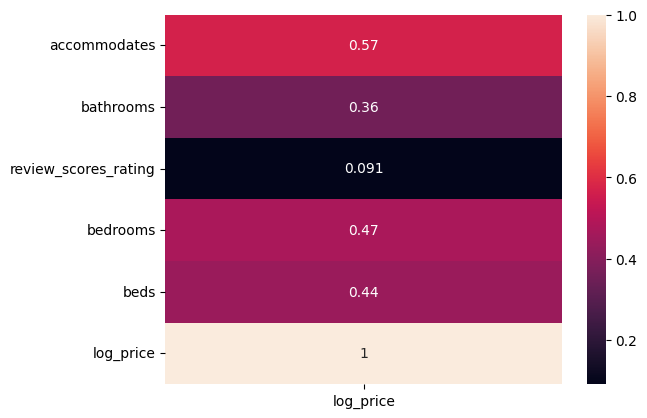

In [16]:
sns.heatmap(data[num].corr()['log_price'].to_frame(),annot=True,fmt='.2g')

In [29]:
threshold = 0.40
t.drop(dependent_var,axis = 0,inplace = True)
selected_feature = t[abs(t)>= threshold]

In [30]:
selected_feature

accommodates    0.567574
bedrooms        0.473212
beds            0.442153
Name: log_price, dtype: float64